# Taller 1: Álgebra Lineal para Machine Learning
## Módulo: Programación Avanzada
**Institución Universitaria Pascual Bravo**

**Estudiante: Diego Alejandro Ríos Vásquez**

Este taller tiene como objetivo aplicar conceptos de álgebra lineal en problemas prácticos de ingeniería de software e inteligencia artificial. En el desarrollo se presentan respuestas conceptuales, implementación en Python y conclusiones técnicas para cada punto solicitado.

# 1. Diagnóstico

## 1.1 Predicción

Considere la transformación:

$$
A =
\begin{bmatrix}
2 & 1\\
0 & 1
\end{bmatrix}
$$

Antes de ejecutar el código:

1. ¿Qué le ocurrirá a un cuadrado dibujado en el plano?
2. ¿Se conservarán los ángulos?
3. ¿Alguna dirección permanecerá sin rotar?
4. ¿Cuál vector crees que podría ser un autovector?

**Respuesta 1:** Un cuadrado en el plano se transformará en un paralelogramo, porque la matriz aplicada combina un escalamiento en el eje horizontal con un efecto de cizallamiento.

**Respuesta 2:** Los ángulos no se conservarán, ya que la transformación no es ortogonal y por tanto modifica la geometría euclidiana de la figura original.

**Respuesta 3:** Sí, existe una dirección que permanece sin rotación: la dirección del eje $x$, dado que los vectores de la forma $(1,0)$ conservan su orientación.

**Respuesta 4:** Un autovector claro es $v=(1,0)$ con autovalor $\lambda=2$. También puede verificarse que $v=(1,-1)$ es autovector asociado a $\lambda=1$.

## 1.2 Aplicación de PCA

Aplica PCA directamente sobre los datos del código a continuación (sin restar la media).

Luego:

1. ¿Qué observa?
2. ¿Por qué el resultado es incorrecto?
3. ¿Qué operación falta y por qué es necesaria geométricamente?

**Respuesta 1:** Al aplicar PCA sin centrar los datos, se observa que la dirección principal queda sesgada por la posición de la nube respecto al origen y no únicamente por su dispersión interna.

**Respuesta 2:** El resultado es incorrecto porque PCA debe capturar varianza alrededor del centro de masa. Si no se centra, la traslación del conjunto introduce un componente artificial en la matriz de covarianza.

**Respuesta 3:** Falta restar la media de cada variable, es decir, construir $X_c = X - \mu$. Geométricamente, este paso traslada la nube al origen para que los autovectores describan la forma y orientación reales de los datos.

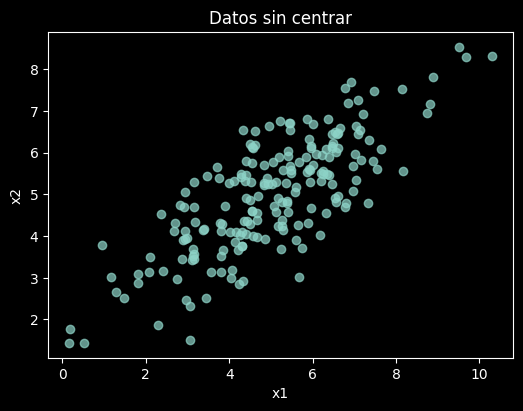

Autovalores SIN centrar: [54.3833  0.6037]
Autovalores CON centrado: [4.4481 0.5182]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset SIN centrar
np.random.seed(3)
data = np.random.multivariate_normal([5, 5], [[3, 2], [2, 2]], 200)

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.7)
plt.gca().set_aspect('equal')
plt.title('Datos sin centrar')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# PCA incorrecto: sin centrar
cov_sin_centrar = (data.T @ data) / data.shape[0]
eigvals_bad, eigvecs_bad = np.linalg.eig(cov_sin_centrar)

# PCA correcto: con centrado
data_centrada = data - data.mean(axis=0)
cov_centrada = np.cov(data_centrada, rowvar=False)
eigvals_ok, eigvecs_ok = np.linalg.eig(cov_centrada)

print('Autovalores SIN centrar:', np.round(np.sort(eigvals_bad)[::-1], 4))
print('Autovalores CON centrado:', np.round(np.sort(eigvals_ok)[::-1], 4))

## 1.3 El siguiente código intenta implementar PCA pero es incorrecto.

1. Identifique el error.
2. Explique por qué ocurre.
3. Corríjalo.

**Respuesta 1:** El error es usar `np.cov(X)` sin especificar la orientación de variables, porque por defecto NumPy usa `rowvar=True` e interpreta cada fila como una variable.

**Respuesta 2:** Esto ocurre porque en este problema las variables están en las columnas y no en las filas; por eso la covarianza calculada con la configuración por defecto no representa correctamente la estructura del conjunto.

**Respuesta 3:** La corrección consiste en centrar los datos y calcular la covarianza con `np.cov(X_c, rowvar=False)`, obteniendo así autovalores y autovectores coherentes para PCA.

In [2]:
X = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[3, 2], [2, 2]],
    size=300
)

# Incorrecto (por defecto rowvar=True):
cov_incorrecta = np.cov(X)
eigvals_bad, eigvecs_bad = np.linalg.eig(cov_incorrecta)

# Correcto para PCA: variables en columnas
X_c = X - X.mean(axis=0)
cov_correcta = np.cov(X_c, rowvar=False)
eigvals, eigvecs = np.linalg.eig(cov_correcta)

print('Forma de X:', X.shape)
print('Forma cov_incorrecta:', cov_incorrecta.shape)
print('Forma cov_correcta:', cov_correcta.shape)
print('Autovalores correctos:', np.round(np.sort(eigvals)[::-1], 4))

Forma de X: (300, 2)
Forma cov_incorrecta: (300, 300)
Forma cov_correcta: (2, 2)
Autovalores correctos: [4.2718 0.4336]


#2. Taller

### 2.1. Operaciones con Vectores: Sistema de Detección de Anomalías
Imagina que monitoreas un servidor. El estado del sistema se representa como un vector $v = [CPU, RAM, DISCO]$.

**Reto:** Calcula la similitud coseno entre el estado actual del servidor y un vector que representa un 'estado crítico'. Si la similitud es muy alta, el sistema debe disparar una alerta.

$$cos(\theta) = \frac{A \cdot B}{||A|| ||B||}$$

Genere al menos 100 vectores con valores aleatorios, pruebe diferentes distribuciones, concluya.

In [6]:
import numpy as np

def calcular_similitud(v_actual, v_critico):
    """Calcula similitud coseno entre dos vectores."""
    numerador = np.dot(v_actual, v_critico)
    denominador = np.linalg.norm(v_actual) * np.linalg.norm(v_critico)
    if denominador == 0:
        return 0.0
    return numerador / denominador

estado_actual = np.array([95, 88, 70])
estado_critico = np.array([100, 100, 100])

similitud = calcular_similitud(estado_actual, estado_critico)
print(f"Similitud con estado crítico (caso puntual): {similitud:.4f}")

# Simulación con al menos 100 vectores y distintas distribuciones
np.random.seed(10)
N = 150
umbral_alerta = 0.97

muestras_normal = np.random.normal(loc=[60, 55, 50], scale=[15, 18, 12], size=(N, 3))
muestras_uniforme = np.random.uniform(low=[20, 15, 10], high=[100, 100, 100], size=(N, 3))
muestras_exponencial = np.random.exponential(scale=[25, 20, 15], size=(N, 3))

# Ajuste para que no haya valores fuera de rango operativo [0, 100]
datasets = {
    'normal': np.clip(muestras_normal, 0, 100),
    'uniforme': np.clip(muestras_uniforme, 0, 100),
    'exponencial': np.clip(muestras_exponencial, 0, 100),
}

for nombre, datos in datasets.items():
    sims = np.array([calcular_similitud(v, estado_critico) for v in datos])
    alertas = np.sum(sims >= umbral_alerta)
    print(f"\nDistribución: {nombre}")
    print(f"  Similitud media: {sims.mean():.4f}")
    print(f"  Similitud máxima: {sims.max():.4f}")
    print(f"  Alertas (sim >= {umbral_alerta}): {alertas}/{N} ({100*alertas/N:.2f}%)")

print('\nConclusión:')
print('- La similitud coseno mide alineación direccional con el estado crítico.')
print('- Distribuciones con más masa en valores altos tienden a generar más alertas.')
print('- El umbral debe calibrarse con históricos para balancear falsos positivos y falsos negativos.')

Similitud con estado crítico (caso puntual): 0.9923

Distribución: normal
  Similitud media: 0.9735
  Similitud máxima: 0.9999
  Alertas (sim >= 0.97): 107/150 (71.33%)

Distribución: uniforme
  Similitud media: 0.9397
  Similitud máxima: 0.9999
  Alertas (sim >= 0.97): 52/150 (34.67%)

Distribución: exponencial
  Similitud media: 0.8270
  Similitud máxima: 0.9939
  Alertas (sim >= 0.97): 4/150 (2.67%)

Conclusión:
- La similitud coseno mide alineación direccional con el estado crítico.
- Distribuciones con más masa en valores altos tienden a generar más alertas.
- El umbral debe calibrarse con históricos para balancear falsos positivos y falsos negativos.


### Conclusión 2.1

La similitud coseno permite evaluar qué tan alineado está el estado operativo del servidor con un patrón crítico. En las simulaciones, la distribución normal produjo una proporción alta de alertas, la uniforme mostró un comportamiento intermedio y la exponencial generó pocas coincidencias con el vector crítico, lo cual evidencia que la forma de la distribución influye directamente en la sensibilidad del sistema de detección. Por esta razón, el umbral de alerta no debe fijarse de manera arbitraria, sino calibrarse con datos históricos para controlar falsos positivos y falsos negativos de forma balanceada.

### 2.2. Transformaciones Lineales y Matrices: Procesamiento de Imágenes
Una imagen en escala de grises puede interpretarse como una matriz:

$$
I \in \mathbb{R}^{m\times n}
$$

donde cada entrada representa la intensidad luminosa de un píxel:

- 0 → negro
- 255 → blanco

Desde el punto de vista del álgebra lineal, la imagen es un vector en un espacio de alta dimensión:

$$
\mathbb{R}^{mn}
$$

y cualquier operación que transforme todos los píxeles de la misma forma puede interpretarse como una **transformación lineal**.

---



Un cambio de brillo puede modelarse como:

$$
T(I) = \alpha I
$$

donde $\alpha > 1$ aumenta el brillo.

**Reto:** Crea una función que reciba una matriz (imagen) y aplique una transformación de escalamiento (multiplicación escalar) para aumentar el brillo, asegurando que los valores no superen 255.

¿Por qué esta operación es una transformación lineal?

¿Qué propiedad de las transformaciones lineales se viola al recortar los valores a 255?

Pruebe con:

$\alpha = 0.5$

$\alpha = 1.5$

$\alpha = 3$

Explique qué ocurre geométricamente con matriz imagen en cada caso.

Pruebe con una imagen real de tamaño pequeño (e.g. 256x256)

Imagen ejemplo original:
 [[10 20]
 [30 40]]

Alpha = 0.5
[[ 5 10]
 [15 20]]

Alpha = 1.5
[[15 30]
 [45 60]]

Alpha = 3.0
[[ 30  60]
 [ 90 120]]


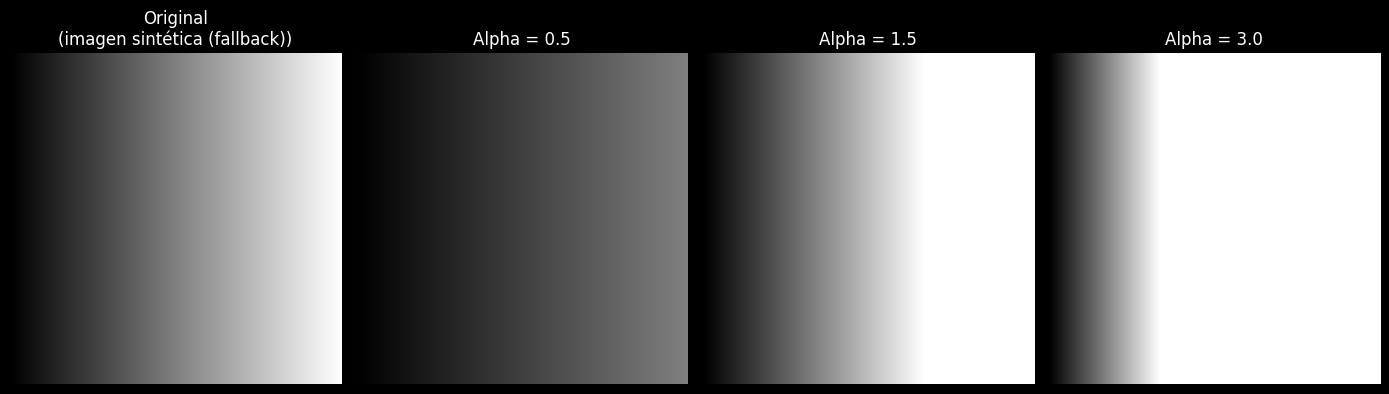

Conclusión geométrica: escalar por alpha estira/contrae el vector imagen en R^(mn).
Con clipping se viola linealidad (aditividad/homogeneidad) porque la saturación recorta valores.


In [4]:
def ajustar_brillo(imagen_matriz, factor):
    """Escala la intensidad de la imagen y recorta al rango [0, 255]."""
    transformada = imagen_matriz.astype(float) * factor
    return np.clip(transformada, 0, 255).astype(np.uint8)

imagen_ejemplo = np.array([[10, 20], [30, 40]], dtype=np.uint8)
print('Imagen ejemplo original:\n', imagen_ejemplo)

for alpha in [0.5, 1.5, 3.0]:
    print(f"\nAlpha = {alpha}")
    print(ajustar_brillo(imagen_ejemplo, alpha))

# Prueba con imagen real pequeña (si hay archivo local).
# Si no existe, se usa una imagen sintética 256x256 para no bloquear la ejecución.
import os
import matplotlib.pyplot as plt

ruta_imagen_local = 'data/imagen_prueba_256x256.png'
if os.path.exists(ruta_imagen_local):
    img = plt.imread(ruta_imagen_local)
    if img.ndim == 3:
        img_gray = (0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2])
    else:
        img_gray = img
    if img_gray.max() <= 1.0:
        img_gray = (img_gray * 255).astype(np.uint8)
    else:
        img_gray = img_gray.astype(np.uint8)
    img_gray = img_gray[:256, :256]
    fuente = 'imagen local real'
else:
    x = np.linspace(0, 255, 256)
    img_gray = np.tile(x, (256, 1)).astype(np.uint8)
    fuente = 'imagen sintética (fallback)'

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original\n({fuente})')
axes[0].axis('off')

for i, alpha in enumerate([0.5, 1.5, 3.0], start=1):
    out = ajustar_brillo(img_gray, alpha)
    axes[i].imshow(out, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'Alpha = {alpha}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print('Conclusión geométrica: escalar por alpha estira/contrae el vector imagen en R^(mn).')
print('Con clipping se viola linealidad (aditividad/homogeneidad) porque la saturación recorta valores.')

### Conclusión 2.2

La transformación $T(I)=\alpha I$ representa un escalamiento del vector imagen en el espacio $\mathbb{R}^{mn}$: cuando $\alpha<1$ la imagen se oscurece, cuando $\alpha>1$ se incrementa el brillo y, para valores altos de $\alpha$, aparece saturación en las zonas claras. Desde el punto de vista algebraico, el escalamiento puro es lineal, pero al aplicar `clip` se introduce una no linealidad porque se recortan intensidades por encima de 255. En consecuencia, la operación final es útil en práctica de procesamiento digital, aunque deja de cumplir estrictamente las propiedades de aditividad y homogeneidad de una transformación lineal.

### 2.3 PCA

Un laboratorio instaló **tres sensores** para medir temperatura en una sala de servidores.

Sin embargo:

- Dos sensores están muy cerca entre sí.
- El tercero está en una ubicación diferente.

El sistema almacena los datos como:

$$
X \in \mathbb{R}^{n\times 3}
$$

donde cada fila es un instante de tiempo y cada columna un sensor.

Su tarea es investigar si realmente necesitamos los 3 sensores o si alguno es redundante. Para ello debe llevar a cabo los siguientes pasos:

1. Visualice los datos. Responda si los vectores parecen independientes.
2. Ejecute PCA siguiendo los pasos vistos en la sesión. Preste particular atención a la matriz de covarianza y a los autovalores y autovectores encontrados. Concluya sobre eso.
3. Proyecte los datos en el nuevo espacio. Reduzca dimensionalidad y concluya sobre los datos iniciales del problema

Forma de X: (200, 3)


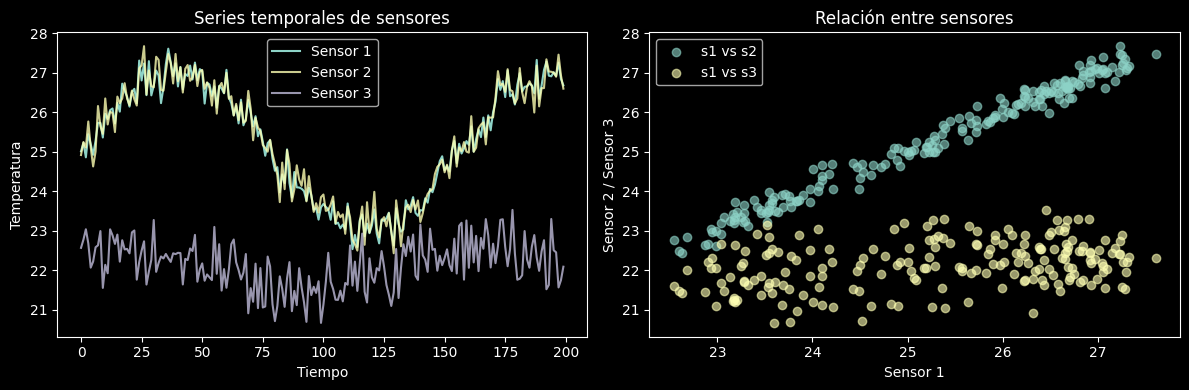


Matriz de correlación entre sensores:
 [[1.    0.99  0.338]
 [0.99  1.    0.317]
 [0.338 0.317 1.   ]]

Matriz de covarianza:
 [[2.0392 2.0031 0.2912]
 [2.0031 2.0081 0.2706]
 [0.2912 0.2706 0.3631]]

Autovalores: [4.0694 0.3211 0.02  ]
Varianza explicada: [0.9227 0.0728 0.0045]
Autovectores (columnas):
 [[ 0.706  -0.0453  0.7067]
 [ 0.7001 -0.1056 -0.7062]
 [ 0.1066  0.9934 -0.0428]]

Dimensión original: 3
Dimensión reducida (2 componentes): 2
Varianza acumulada con 2 componentes: 0.9955


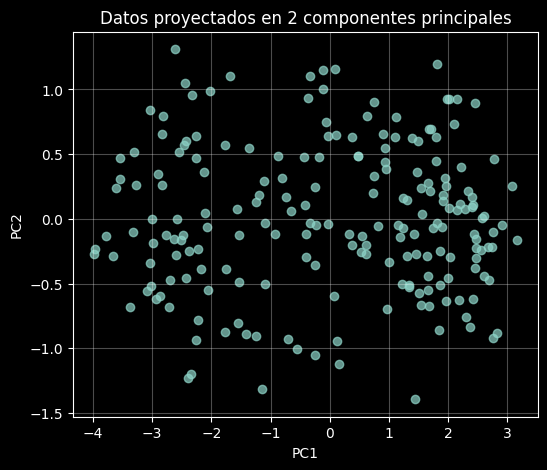


Conclusiones:
- Sensor 1 y Sensor 2 son altamente redundantes (correlación alta).
- PCA concentra la mayor varianza en pocas componentes, permitiendo reducir dimensión.
- En este escenario, se puede representar casi toda la información con 2 sensores/componentes.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)
n = 200

sensor1 = 25 + 2*np.sin(np.linspace(0, 8, n)) + np.random.normal(0, 0.3, n)
sensor2 = sensor1 + np.random.normal(0, 0.2, n)
sensor3 = 22 + 0.5*np.sin(np.linspace(0, 8, n) + 1) + np.random.normal(0, 0.5, n)

X = np.column_stack((sensor1, sensor2, sensor3))
print('Forma de X:', X.shape)

# 1) Visualización: señales y relaciones entre sensores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sensor1, label='Sensor 1')
axes[0].plot(sensor2, label='Sensor 2', alpha=0.8)
axes[0].plot(sensor3, label='Sensor 3', alpha=0.8)
axes[0].set_title('Series temporales de sensores')
axes[0].set_xlabel('Tiempo')
axes[0].set_ylabel('Temperatura')
axes[0].legend()

axes[1].scatter(sensor1, sensor2, alpha=0.6, label='s1 vs s2')
axes[1].scatter(sensor1, sensor3, alpha=0.6, label='s1 vs s3')
axes[1].set_title('Relación entre sensores')
axes[1].set_xlabel('Sensor 1')
axes[1].set_ylabel('Sensor 2 / Sensor 3')
axes[1].legend()
plt.tight_layout()
plt.show()

corr = np.corrcoef(X, rowvar=False)
print('\nMatriz de correlación entre sensores:\n', np.round(corr, 3))

# 2) PCA paso a paso
X_centered = X - X.mean(axis=0)
cov = np.cov(X_centered, rowvar=False)
eigvals, eigvecs = np.linalg.eig(cov)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
var_ratio = eigvals / eigvals.sum()

print('\nMatriz de covarianza:\n', np.round(cov, 4))
print('\nAutovalores:', np.round(eigvals, 4))
print('Varianza explicada:', np.round(var_ratio, 4))
print('Autovectores (columnas):\n', np.round(eigvecs, 4))

# 3) Proyección y reducción de dimensionalidad
Z = X_centered @ eigvecs
Z2 = X_centered @ eigvecs[:, :2]

print('\nDimensión original:', X.shape[1])
print('Dimensión reducida (2 componentes):', Z2.shape[1])
print(f'Varianza acumulada con 2 componentes: {var_ratio[:2].sum():.4f}')

plt.figure(figsize=(6, 5))
plt.scatter(Z2[:, 0], Z2[:, 1], alpha=0.7)
plt.title('Datos proyectados en 2 componentes principales')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.3)
plt.show()

print('\nConclusiones:')
print('- Sensor 1 y Sensor 2 son altamente redundantes (correlación alta).')
print('- PCA concentra la mayor varianza en pocas componentes, permitiendo reducir dimensión.')
print('- En este escenario, se puede representar casi toda la información con 2 sensores/componentes.')

### Conclusión 2.3

El análisis muestra que los sensores 1 y 2 registran información muy similar, lo cual se confirma por su alta correlación y por el peso que comparten en la primera componente principal. Los autovalores indican que casi toda la variabilidad del sistema se concentra en las dos primeras componentes, por lo que la reducción de 3 a 2 dimensiones conserva prácticamente toda la información relevante. En términos prácticos, esto sugiere que existe redundancia instrumental y que el sistema puede simplificarse sin pérdida significativa de capacidad descriptiva.